In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
path_to_data = '../../data/broader_context/chem/'
path_to_final_figures = '../../../paper/final_figures/'

In [4]:
alhic1901_IC = pd.read_csv(path_to_data+'ALHIC1901_MajorIons.csv')
alhic1903_IC = pd.read_csv(path_to_data+'ALHIC1903_MajorIons.csv')
alhic1901_ICPMS = pd.read_csv(path_to_data+'ALHIC1901_TraceElements.csv')
alhic1903_ICPMS = pd.read_csv(path_to_data+'ALHIC1903_TraceElements.csv')

In [15]:
alhic1901_IC.columns

Index(['Date Analyzed', 'Sample ID', 'Core', 'Section', 'Top Depth (m)',
       'Bot Depth (m)', 'Cl- (µg/L)', 'NO3- (µg/L)', 'SO42- (µg/L)',
       'Na+ (µg/L)', 'K+ (µg/L)', 'Mg2+ (µg/L)', 'Ca2+ (µg/L)', 'ion_balance'],
      dtype='object')

In [10]:
def add_ion_balance(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add an ion_balance column to a major-ion dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing major ion concentration columns:
        Cl- (µg/L), NO3- (µg/L), SO42- (µg/L), Na+ (µg/L),
        K+ (µg/L), Mg2+ (µg/L), Ca2+ (µg/L)

    Returns
    -------
    pd.DataFrame
        Copy of the input dataframe with a new column:
        ion_balance = anion - cation
    """
    out = df.copy()

    # Convert from micrograms per liter to grams per liter
    ug_per_l_to_g_per_l = 1e-6

    cl_mol = (out["Cl- (µg/L)"] * ug_per_l_to_g_per_l) / 35.45
    na_mol = (out["Na+ (µg/L)"] * ug_per_l_to_g_per_l) / 22.99
    ca_mol = (out["Ca2+ (µg/L)"] * ug_per_l_to_g_per_l) / 40.08
    so4_mol = (out["SO42- (µg/L)"] * ug_per_l_to_g_per_l) / 96.06
    mg_mol = (out["Mg2+ (µg/L)"] * ug_per_l_to_g_per_l) / 24.305
    no3_mol = (out["NO3- (µg/L)"] * ug_per_l_to_g_per_l) / 62.01
    k_mol = (out["K+ (µg/L)"] * ug_per_l_to_g_per_l) / 39.10

    # Match the MATLAB handling used for ION1903:
    # negative K values are treated as missing
    k_mol = k_mol.mask(k_mol < 0)

    anion = 2 * so4_mol + no3_mol + cl_mol
    cation = 2 * ca_mol + 2 * mg_mol + k_mol + na_mol

    out["ion_balance"] = anion - cation

    return out

In [11]:
# impliment function to add ion balance to both dataframes
alhic1901_IC = add_ion_balance(alhic1901_IC)
alhic1903_IC = add_ion_balance(alhic1903_IC)

In [39]:
# add a column called 'glacial' or 'interglacial' to the ALHIC1903 dataframe. Assign to MIS5e or MIS6 based on the 'Age_ka' column
mis5e_mask = alhic1903_IC["Age (ka)"].between(115, 128.3, inclusive="both")
mis6_mask = alhic1903_IC["Age (ka)"].between(134.4, 191, inclusive="both")

alhic1903_IC["glacial_interglacial"] = pd.NA
alhic1903_IC.loc[mis5e_mask, "glacial_interglacial"] = "interglacial"
alhic1903_IC.loc[mis6_mask, "glacial_interglacial"] = "glacial"

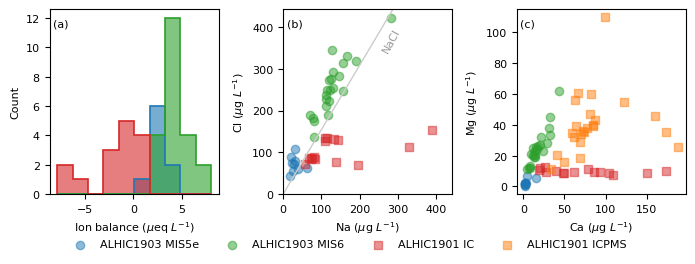

In [40]:
# Make the plot
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

# Colors and markers
color_1903_mis5e = "#1f77b4"
color_1903_mis6 = "#2ca02c"
color_1901_ic = "#d62728"
color_1901_icpms = "#ff7f0e"
marker_1903 = "o"
marker_1901 = "s"
point_alpha = 0.5

# Prepare ion balance data (microeq/L)
ion_1901 = (alhic1901_IC["ion_balance"] * 1e6).dropna()
ion_1903_mis5e = (alhic1903_IC.loc[mis5e_mask, "ion_balance"] * 1e6).dropna()
ion_1903_mis6 = (alhic1903_IC.loc[mis6_mask, "ion_balance"] * 1e6).dropna()
all_ion = pd.concat([ion_1901, ion_1903_mis5e, ion_1903_mis6], ignore_index=True)
bins = np.histogram_bin_edges(all_ion, bins="auto")

# Prepare IC data for Cl and Na (ug/L)
cl_1901 = alhic1901_IC["Cl- (µg/L)"]
na_1901 = alhic1901_IC["Na+ (µg/L)"]
cl_1903 = alhic1903_IC["Cl- (µg/L)"]
na_1903 = alhic1903_IC["Na+ (µg/L)"]

# Prepare Mg and Ca data (IC + ICPMS) (ug/L)
mg_1901_ic = alhic1901_IC["Mg2+ (µg/L)"]
ca_1901_ic = alhic1901_IC["Ca2+ (µg/L)"]
mg_1903_ic = alhic1903_IC["Mg2+ (µg/L)"]
ca_1903_ic = alhic1903_IC["Ca2+ (µg/L)"]

mg_1901_icpms = alhic1901_ICPMS["Mg (ug/L)"]
ca_1901_icpms = alhic1901_ICPMS["Ca (ug/L)"]

fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))
ax1, ax2, ax3 = axes

# Subplot 1: Ion balance histogram
ax1.hist(ion_1903_mis5e, bins=bins, color=color_1903_mis5e, alpha=0.6, label="ALHIC1903 MIS5e")
ax1.hist(ion_1903_mis6, bins=bins, color=color_1903_mis6, alpha=0.6, label="ALHIC1903 MIS6")
ax1.hist(ion_1901, bins=bins, color=color_1901_ic, alpha=0.6, label="ALHIC1901 IC")
ax1.hist(ion_1903_mis5e, bins=bins, histtype="step", color=color_1903_mis5e, linewidth=1.2)
ax1.hist(ion_1903_mis6, bins=bins, histtype="step", color=color_1903_mis6, linewidth=1.2)
ax1.hist(ion_1901, bins=bins, histtype="step", color=color_1901_ic, linewidth=1.2)
ax1.set_xlabel(r"Ion balance ($\mu$eq $L^{-1}$)")
ax1.set_ylabel("Count")
#ax1.set_title("Ion balance")
ax1.text(0.02, 0.95, "(a)", transform=ax1.transAxes, ha="left", va="top")

# Subplot 2: Na vs Cl (IC) with 1:1 line
ax2.scatter(na_1903[mis5e_mask], cl_1903[mis5e_mask], color=color_1903_mis5e, marker=marker_1903, alpha=point_alpha, label="ALHIC1903 MIS5e")
ax2.scatter(na_1903[mis6_mask], cl_1903[mis6_mask], color=color_1903_mis6, marker=marker_1903, alpha=point_alpha, label="ALHIC1903 MIS6")
ax2.scatter(na_1901, cl_1901, color=color_1901_ic, marker=marker_1901, alpha=point_alpha, label="ALHIC1901 IC")

max_val = np.nanmax(pd.concat([na_1901, cl_1901, na_1903, cl_1903], ignore_index=True))
ax2.plot([0, max_val], [0, max_val*1.54], color="0.8", linewidth=1)
ax2.set_xlim(0, max_val * 1.05)
ax2.set_ylim(0, max_val * 1.05)
ax2.set_xlabel(r"Na ($\mu$g $L^{-1}$)")
ax2.set_ylabel(r"Cl ($\mu$g $L^{-1}$)")
#ax2.set_title("Na vs Cl")
ax2.text(0.02, 0.95, "(b)", transform=ax2.transAxes, ha="left", va="top")

# Label the 1:1 line with matching rotation
p1 = ax2.transData.transform((0, 0))
p2 = ax2.transData.transform((1, 1))
angle = np.degrees(np.arctan2(p2[1]*1.54 - p1[1]*1.54, p2[0] - p1[0]))
ax2.text(max_val * 0.65, max_val * 0.8, "NaCl", color="0.6", rotation=angle, rotation_mode="anchor")

# Subplot 3: Ca vs Mg (IC + ICPMS)
ax3.scatter(ca_1903_ic[mis5e_mask], mg_1903_ic[mis5e_mask], color=color_1903_mis5e, marker=marker_1903, alpha=point_alpha, label="ALHIC1903 MIS5e")
ax3.scatter(ca_1903_ic[mis6_mask], mg_1903_ic[mis6_mask], color=color_1903_mis6, marker=marker_1903, alpha=point_alpha, label="ALHIC1903 MIS6")
ax3.scatter(ca_1901_ic, mg_1901_ic, color=color_1901_ic, marker=marker_1901, alpha=point_alpha, label="ALHIC1901 IC")
ax3.scatter(ca_1901_icpms, mg_1901_icpms, color=color_1901_icpms, marker=marker_1901, alpha=point_alpha, label="ALHIC1901 ICPMS")
ax3.set_xlabel(r"Ca ($\mu$g $L^{-1}$)")
ax3.set_ylabel(r"Mg ($\mu$g $L^{-1}$)")
ax3.text(0.02, 0.95, "(c)", transform=ax3.transAxes, ha="left", va="top")

# One legend centered below all subplots
handles, labels = ax3.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.05))

# use tight layout
fig.tight_layout()

# save plots
# save final figure as pdf and png
fig.savefig(path_to_final_figures+'pdf/figure9.pdf', dpi=300)
fig.savefig(path_to_final_figures+'png/figure9.png', dpi=300)

plt.show()